Discovery years from 1992 to 2025

Year summary:
count    6004.000000
mean     2016.821452
std         4.864422
min      1992.000000
25%      2014.000000
50%      2016.000000
75%      2021.000000
max      2025.000000
Name: disc_year, dtype: float64


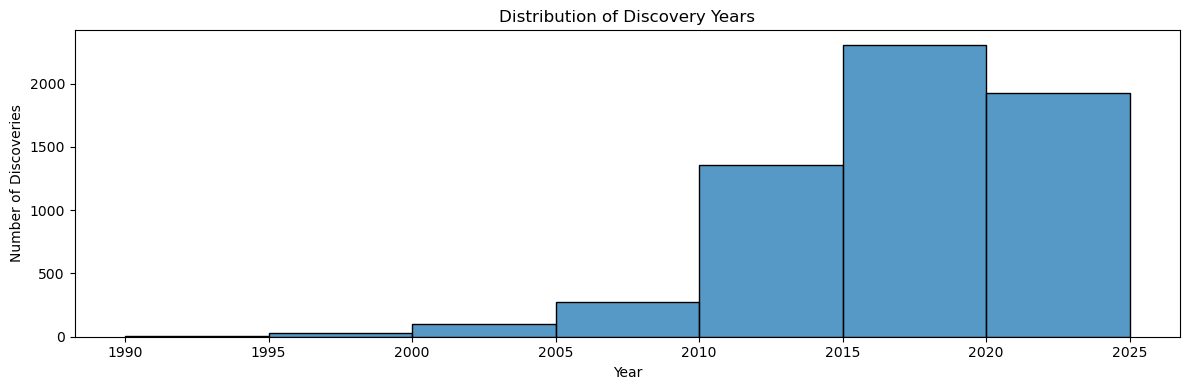

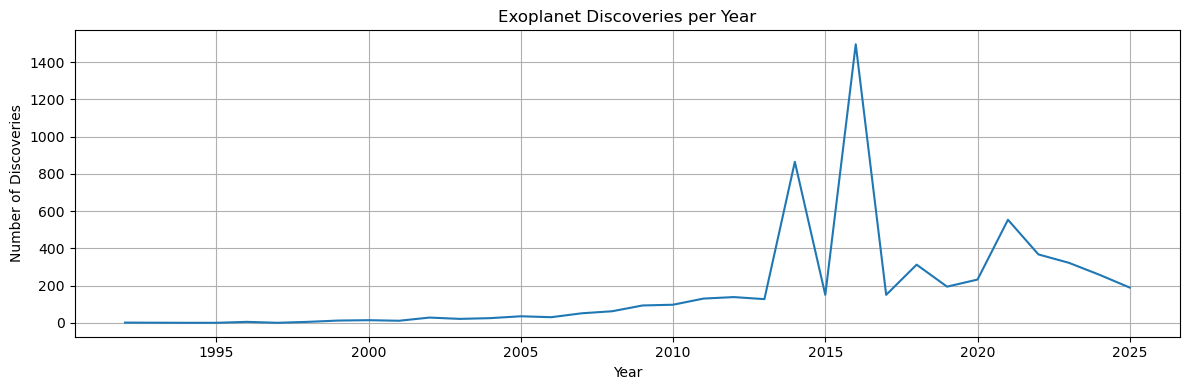

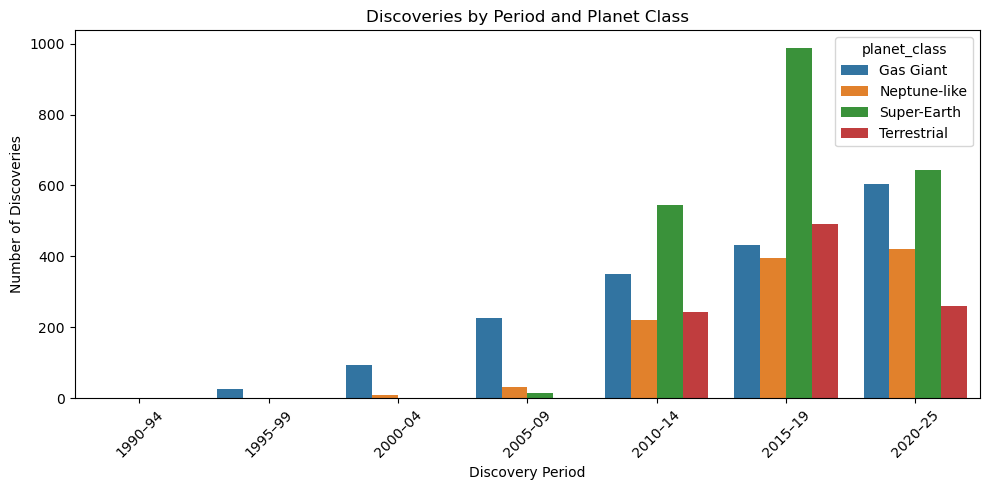


Features used for mean calculation:
['sy_snum', 'sy_pnum', 'pl_controv_flag', 'pl_orbper']

Mean feature values by discovery period:
              sy_snum   sy_pnum  pl_controv_flag      pl_orbper
disc_period                                                    
1990–94      1.000000  3.000000         0.000000      63.338433
1995–99      1.481481  1.851852         0.037037     262.995852
2000–04      1.326923  1.586538         0.009615     675.260904
2005–09      1.228261  1.528986         0.000000   28165.724537
2010–14      1.132256  2.515797         0.011021     214.073965
2015–19      1.078057  1.503036         0.003903    2709.348310
2020–25      1.078879  1.593150         0.002595  214588.678088


/tmp/ipykernel_1384/3833865710.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_period = df.groupby("disc_period")[features_q2].mean()


<Figure size 1200x500 with 0 Axes>

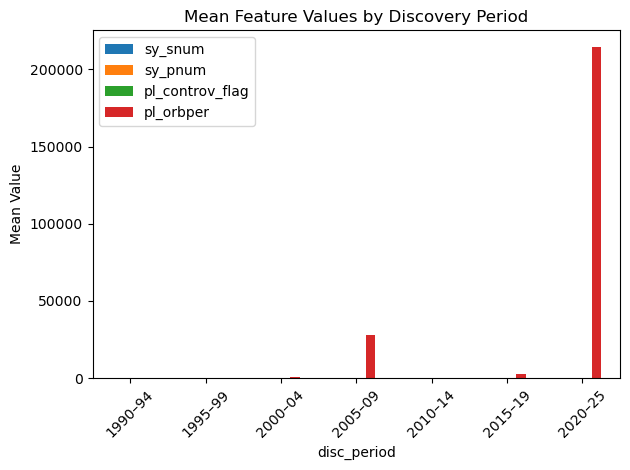

In [9]:
# Q2 – Investigate exoplanet discovery patterns over time

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---------------------------
# 0. Load data
# ---------------------------
df = pd.read_csv("exoplanet.csv")

# užtikrinam, kad metai būtų integer
df["disc_year"] = pd.to_numeric(df["disc_year"], errors="coerce")
df = df.dropna(subset=["disc_year"])
df["disc_year"] = df["disc_year"].astype(int)

years = df["disc_year"]

# ---------------------------
# 1. Discovery year summary + 5-year bins histogram
# ---------------------------

print("Discovery years from", years.min(), "to", years.max())
print("\nYear summary:")
print(years.describe())

# 5 metų intervalai, kurie baigiasi ties max year (2025)
start = (years.min() // 5) * 5
end = years.max()     # baigiasi ties 2025
bin_edges = list(range(start, end + 1, 5))
bin_edges.append(end)              # garantuojam, kad paskutinis bin == 2025
bin_edges = sorted(set(bin_edges)) # pašalinam dublikatus

plt.figure(figsize=(12, 4))
sns.histplot(years, bins=bin_edges, kde=False)
plt.title("Distribution of Discovery Years")
plt.xlabel("Year")
plt.ylabel("Number of Discoveries")
plt.tight_layout()
plt.show()

# ---------------------------
# 2. Create broader time periods (eras)
# ---------------------------

bins = [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2026]
labels = ["1990–94", "1995–99", "2000–04", "2005–09",
          "2010–14", "2015–19", "2020–25"]

df["disc_period"] = pd.cut(df["disc_year"], bins=bins, labels=labels, right=False)

# ---------------------------
# 3. Discoveries per year (line plot)
# ---------------------------

plt.figure(figsize=(12, 4))
df["disc_year"].value_counts().sort_index().plot(kind="line")
plt.title("Exoplanet Discoveries per Year")
plt.xlabel("Year")
plt.ylabel("Number of Discoveries")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------------------
# 4. Discoveries per period and class
# ---------------------------

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="disc_period", hue="planet_class")
plt.title("Discoveries by Period and Planet Class")
plt.xlabel("Discovery Period")
plt.ylabel("Number of Discoveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------
# 5. Mean feature values per period
# ---------------------------

# pasirenkam tik skaitines kolonas
numeric_cols = df.select_dtypes(include=["number"]).columns

# metai nereikalingi vidurkių analizėje
cols_to_exclude = ["disc_year"]
features_q2 = [c for c in numeric_cols if c not in cols_to_exclude]

# kad nebūtų bardako su 20 kolonų – imam pirmas 4
features_q2 = features_q2[:4]

print("\nFeatures used for mean calculation:")
print(features_q2)

mean_by_period = df.groupby("disc_period")[features_q2].mean()

print("\nMean feature values by discovery period:")
print(mean_by_period)

plt.figure(figsize=(12, 5))
mean_by_period.plot(kind="bar")
plt.title("Mean Feature Values by Discovery Period")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
